In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw = pd.read_csv(url)
df_raw.to_csv('Customer_Churn_Dataset_Surendra.csv', index=False)

In [4]:
print("Shape:", df.shape)
df.info()
df.describe(include='all')

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nBlank TotalCharges:", (df['TotalCharges'] == ' ').sum())

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Blank TotalCharges: 11


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # tenure=0 customers haven't been billed yet

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})  # readability for charts

In [7]:
df.to_csv('Cleaned_Customer_Churn_Dataset_Surendra.csv', index=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


/tmp/ipykernel_1609/2322767852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


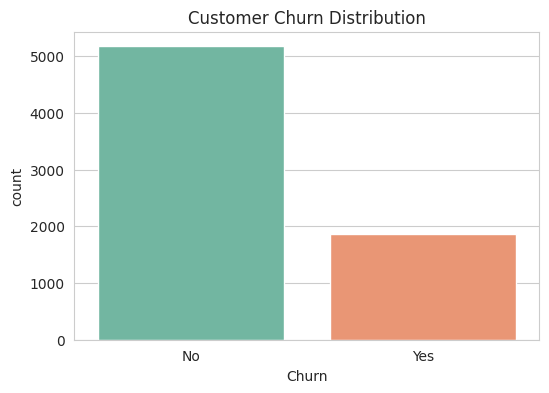

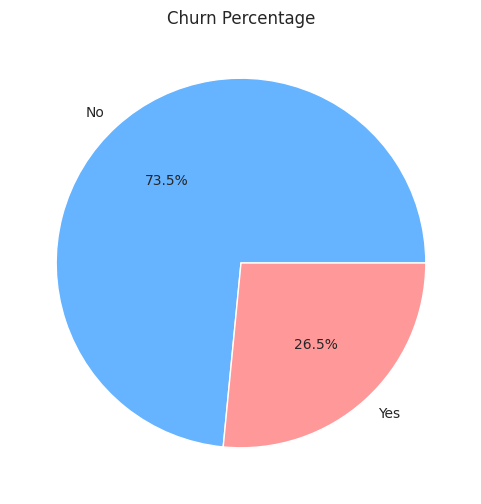

In [8]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print((churn_counts / len(df) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.show()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Churn Percentage')
plt.show()

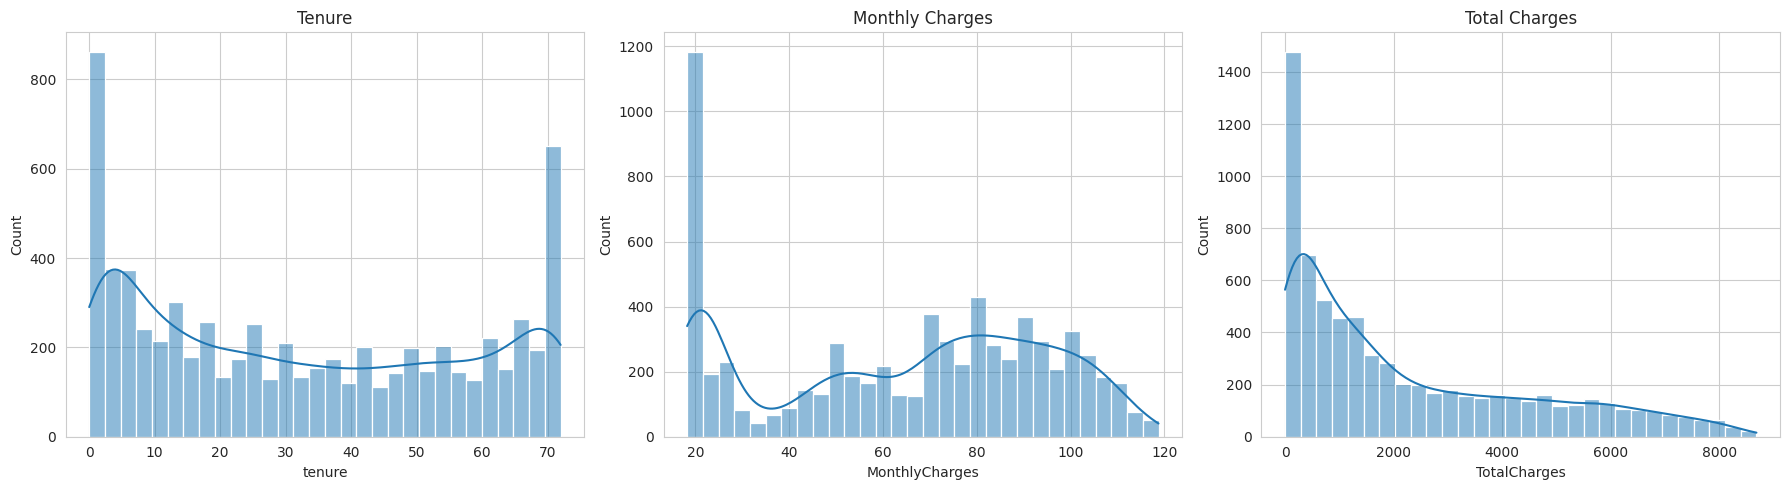

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235
dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0]).set_title('Tenure')
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1]).set_title('Monthly Charges')
sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[2]).set_title('Total Charges')
plt.tight_layout()
plt.show()

print(df[['tenure','MonthlyCharges','TotalCharges']].skew())

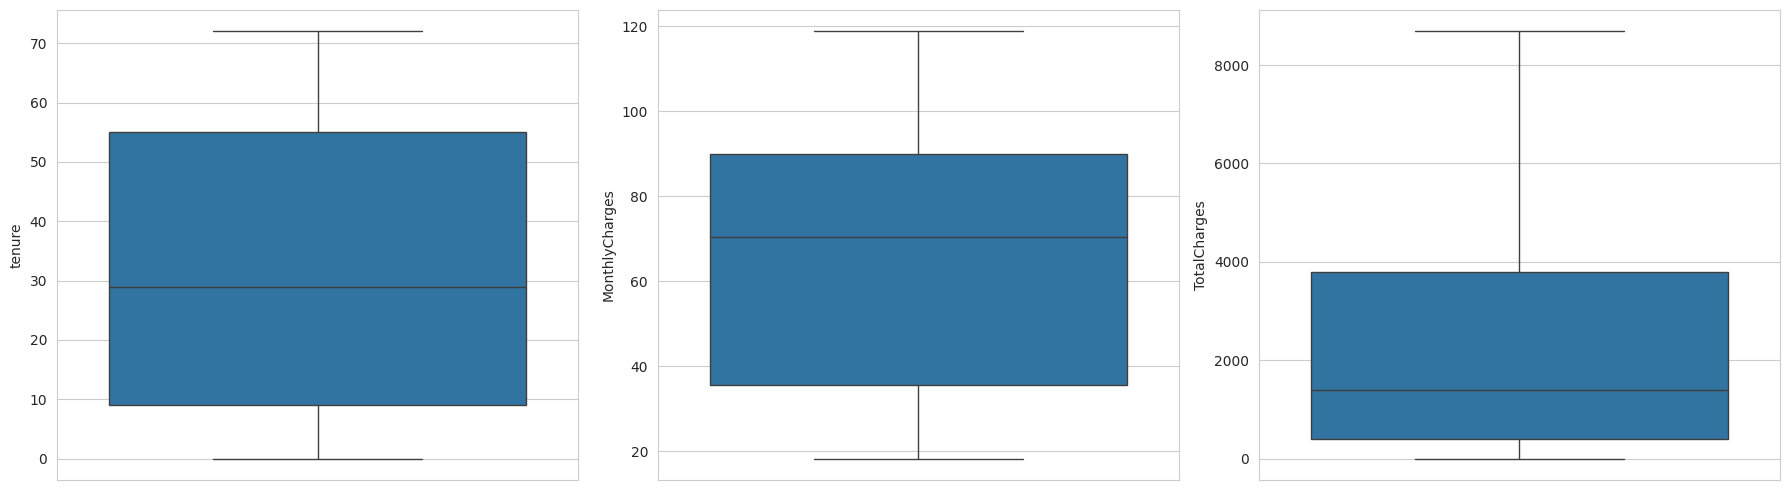

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.boxplot(y=df['tenure'], ax=axes[0])
sns.boxplot(y=df['MonthlyCharges'], ax=axes[1])
sns.boxplot(y=df['TotalCharges'], ax=axes[2])
plt.tight_layout()
plt.show()

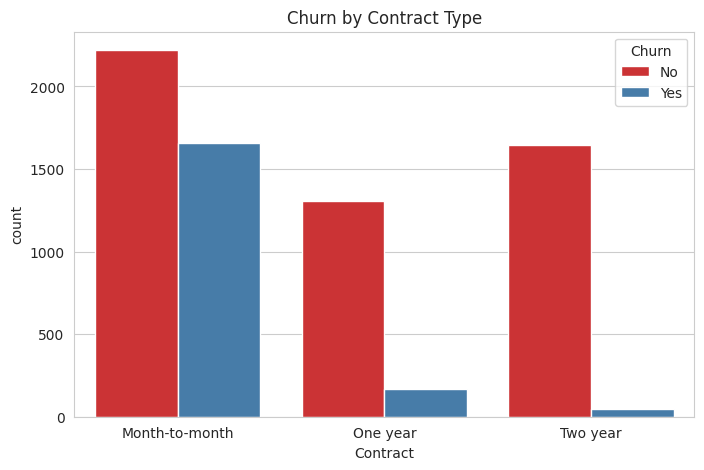

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type')
plt.show()

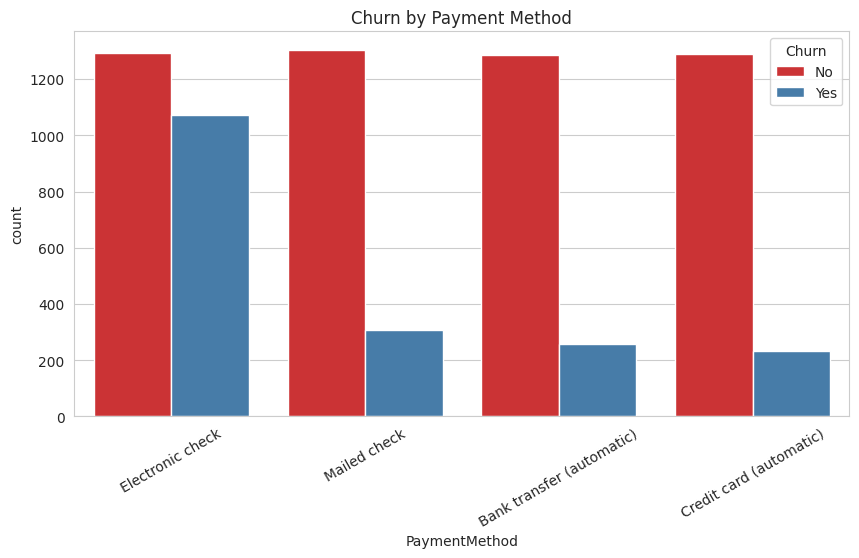

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set1')
plt.xticks(rotation=30)
plt.title('Churn by Payment Method')
plt.show()

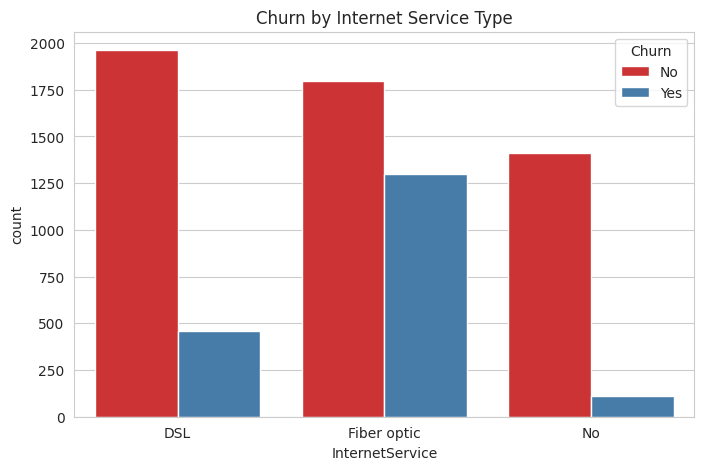

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Internet Service Type')
plt.show()

/tmp/ipykernel_1609/4168745463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0]).set_title('Tenure vs Churn')
/tmp/ipykernel_1609/4168745463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1]).set_title('Monthly Charges vs Churn')


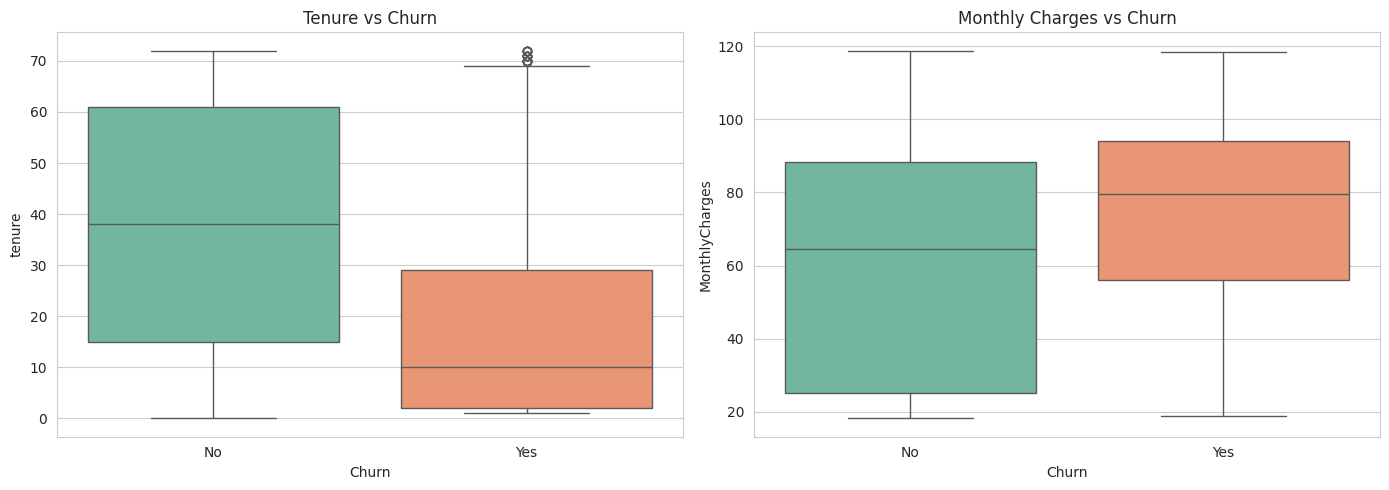

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2', ax=axes[0]).set_title('Tenure vs Churn')
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2', ax=axes[1]).set_title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

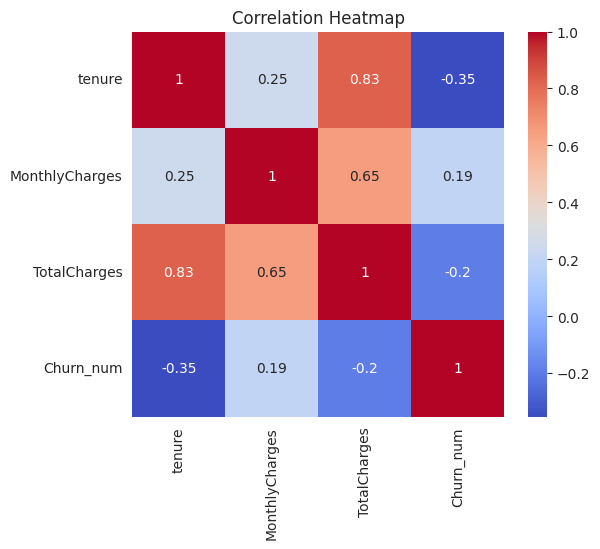

In [15]:
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']

plt.figure(figsize=(6,5))
sns.heatmap(df_corr[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

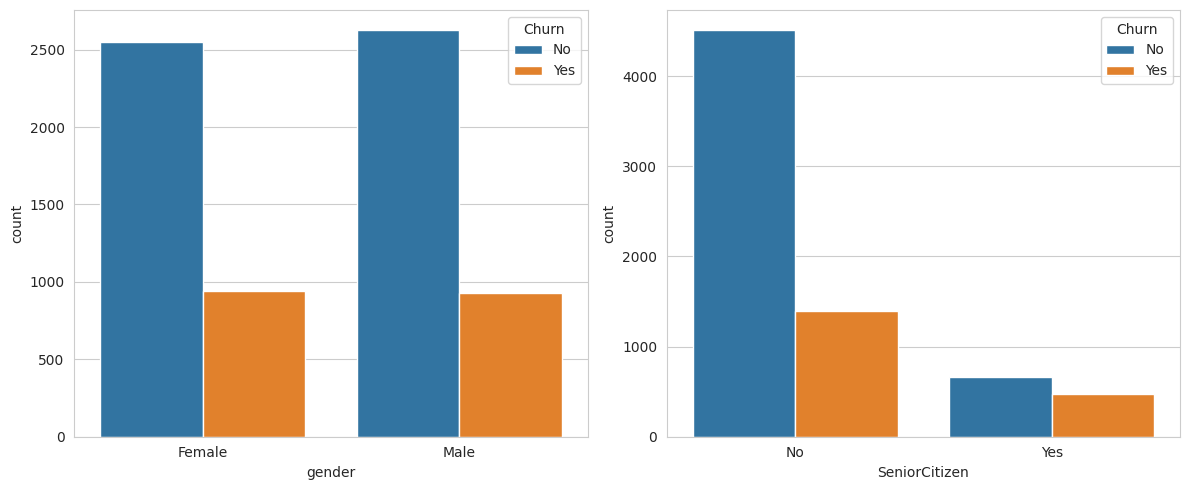

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0])
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

## Key Insights from EDA

1. **Overall churn rate**: About 26.5% of customers in this dataset have churned,
   while 73.5% have stayed. This is a meaningful chunk of the customer base, so
   churn is a real business problem worth investigating.

2. **Contract type matters a lot**: Month-to-month customers churn at a much
   higher rate than customers on One year or Two year contracts. Customers with
   no long-term commitment are far more likely to leave, which suggests offering
   incentives to move customers onto longer contracts could reduce churn.

3. **Payment method is a strong signal**: Customers who pay via Electronic check
   churn noticeably more than those using automatic payment methods (bank
   transfer or credit card). Automatic payments may correlate with more
   "stuck around" or loyal customers, or electronic check users may be more
   price-sensitive and quicker to leave.

4. **Internet service type**: Fiber optic customers churn more than DSL
   customers, despite fiber being the "premium" service. This could point to
   pricing concerns or service quality/reliability issues with fiber that are
   pushing customers away.

5. **Tenure is the clearest differentiator**: Customers who churn tend to have
   much lower tenure (fewer months as a customer) than those who stay. This
   matches intuition — new customers haven't yet built loyalty, and the first
   few months are the highest-risk period for losing a customer.

6. **Monthly charges**: Churned customers tend to have somewhat higher monthly
   charges than retained customers, suggesting price sensitivity plays a role
   in the decision to leave.

7. **Demographics (gender, senior citizen)**: Gender shows almost no difference
   in churn rate between male and female customers. Senior citizens churn at a
   slightly higher rate than non-senior customers.

8. **Correlation findings**: Tenure has a negative correlation with churn
   (longer-tenured customers churn less), while monthly charges has a positive
   correlation with churn. Total charges is strongly tied to tenure since it
   accumulates over time.

## Recommendations
- Target retention campaigns at month-to-month, low-tenure customers, since
  they are the highest-risk segment.
- Investigate why fiber optic customers churn more — possibly pricing or
  service reliability.
- Encourage electronic check users to switch to automatic payment methods,
  which seem linked to lower churn.